# Montecarlo

In [12]:
import random
import time
import math

def calculate_pi_serial(num_samples):
    inside_circle = 0
    
    for _ in range(num_samples):
        x = random.uniform(-1, 1)
        y = random.uniform(-1, 1)
        
        # Cek apakah titik berada dalam lingkaran
        if x**2 + y**2 <= 1:
            inside_circle += 1
    
    pi_estimate = 4 * inside_circle / num_samples
    return pi_estimate

# Testing
if __name__ == "__main__":
    num_samples = 10_000_000
    
    start_time = time.time()
    pi_est = calculate_pi_serial(num_samples)
    end_time = time.time()
    
    print(f"Estimasi π: {pi_est}")
    print(f"Nilai asli π: {math.pi}")
    print(f"Error: {abs(pi_est - math.pi)}")
    print(f"Waktu eksekusi: {end_time - start_time:.4f} detik")


Estimasi π: 3.1410344
Nilai asli π: 3.141592653589793
Error: 0.0005582535897930008
Waktu eksekusi: 3.4718 detik


In [13]:
import multiprocessing
import random
import time
import math

def monte_carlo_chunk(chunk_size):
    """Menghitung titik dalam lingkaran untuk sejumlah sampel"""
    inside = 0
    for _ in range(chunk_size):
        x = random.uniform(-1, 1)
        y = random.uniform(-1, 1)
        if x**2 + y**2 <= 1:
            inside += 1
    return inside

def calculate_pi_parallel(num_samples, num_processes):
    """Menghitung π menggunakan multiprocessing"""
    chunk_size = num_samples // num_processes
    
    # Buat pool worker
    with multiprocessing.Pool(processes=num_processes) as pool:
        results = pool.map(monte_carlo_chunk, [chunk_size] * num_processes)
    
    total_inside = sum(results)
    pi_estimate = 4 * total_inside / (chunk_size * num_processes)
    return pi_estimate

# Testing dengan berbagai jumlah proses
if __name__ == "__main__":
    num_samples = 10_000_000
    
    for num_procs in [1, 2, 4, 8, 16, 32]:
        start_time = time.time()
        pi_est = calculate_pi_parallel(num_samples, num_procs)
        end_time = time.time()
        
        print(f"\nProses: {num_procs}")
        print(f"  Estimasi π: {pi_est}")
        print(f"  Waktu: {end_time - start_time:.4f} detik")



Proses: 1
  Estimasi π: 3.1411432
  Waktu: 3.3486 detik

Proses: 2
  Estimasi π: 3.1414488
  Waktu: 1.5815 detik

Proses: 4
  Estimasi π: 3.1421164
  Waktu: 0.8753 detik

Proses: 8
  Estimasi π: 3.142024
  Waktu: 0.7703 detik

Proses: 16
  Estimasi π: 3.1419112
  Waktu: 0.5600 detik

Proses: 32
  Estimasi π: 3.141938
  Waktu: 0.6289 detik


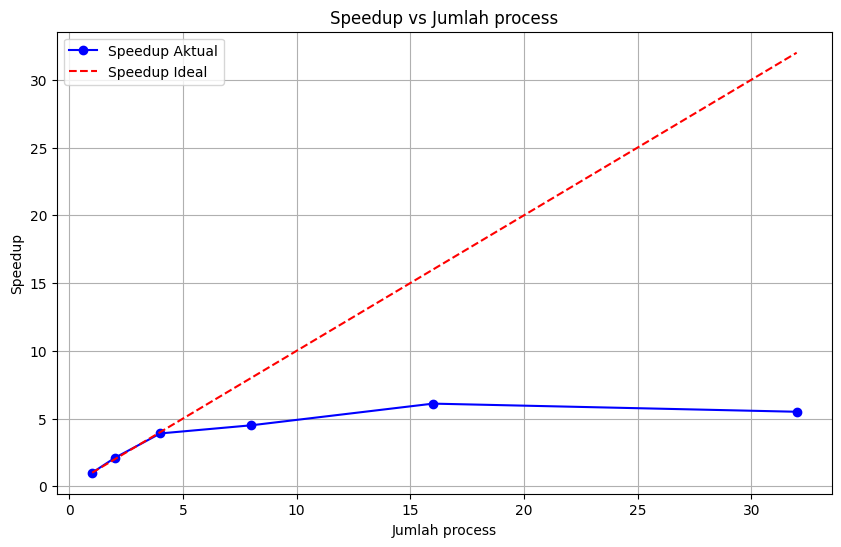

In [1]:
import matplotlib.pyplot as plt

# Data contoh
process_counts = [1, 2, 4, 8, 16,32]
speedups = [1.0, 2.1, 3.9, 4.5, 6.1, 5.5]

plt.figure(figsize=(10, 6))
plt.plot(process_counts, speedups, 'bo-', label='Speedup Aktual')
plt.plot(process_counts, process_counts, 'r--', label='Speedup Ideal')
plt.xlabel('Jumlah process')
plt.ylabel('Speedup')
plt.title('Speedup vs Jumlah process')
plt.legend()
plt.grid(True)
plt.savefig('speedup_analysis.png')
plt.show()
